# ACCESS-rOM3 superAUS Scaling

End-to-end pipeline generating scaling plots for [ACCESS-rOM3 MC superAUS configuration](https://github.com/ACCESS-NRI/access-om3-configs/tree/helen/superaus).

In [1]:
%load_ext autoreload
%autoreload 2

## Package versions

In [2]:
from importlib.metadata import version
for pkg in ("access.config.utils", "access.profiling",):
    print(f"{pkg}: {version(pkg)}")

access.config.utils: 0.4
access.profiling: 0.2.dev29+g2022a4bd3


## Setup
The following variables control where the configurations and model run outputs are saved.

In [3]:
## Imports
from pathlib import Path

from access.config.parallel_domain import Domain
from access.profiling.access_models import OM3Profiling, OM3Configuration

test_path = f"/scratch/tm70/model_scaling/ACCESS-rOM3/helen/superaus"
archive_path = f"/g/data/tm70/model_scaling/ACCESS-rOM3/helen/superaus/archive"

GRID = Domain(shape=(1834, 1662))
superAUS = OM3Configuration(
    name="superAUS",
    ocean=GRID,
    sea_ice=GRID,
    atmosphere=GRID,
    runoff=GRID,
    data_sea_ice=True,
)

om3_profiling = OM3Profiling(work_dir=Path(test_path), archive_dir=Path(archive_path), configuration=superAUS)
om3_profiling.set_control(repository="https://github.com/ACCESS-NRI/access-om3-configs.git", commit="37f09d5")

## Generate experiments

We will perform a simple scaling study, varying the total number of nodes used over `[10, 12, 14, 16, 18, 20, 24]`. We will keep the ration of cores assigned to each component constant.

In [4]:
from access.config.parallel_allocation_strategies import RootAllocation, FreeAllocation, WholeRangeAllocation, WeightedAllocation
from access.config.parallel_constraints import SubdomainAspectRatioConstraint, RankRatioGroupConstraint, MaxWastedCoreFractionConstraint, EqualCoresGroupConstraint

# Define how the cores should be allocated to the components
allocation_strategy = RootAllocation(
    subcomponents={
        "ocn": WeightedAllocation(weight=25,),
        "shared": WeightedAllocation(weight=1,
            subcomponents={
                "ice": WholeRangeAllocation(),
                "cpl": WholeRangeAllocation(),
                "rof": WholeRangeAllocation(),
                "atm": WholeRangeAllocation(),
            },
        ),
    },
    local_constraints=(MaxWastedCoreFractionConstraint(max_fraction=0.001),),
)


#from access.config.parallel_layouts import iter_layouts
#layouts = list(iter_layouts(superAUS.parallel_component, 14*104, allocations=allocation_strategy))
#print(len(layouts))
#for layout in layouts:
#    print(layout.sub_layouts[1])
#    print(layout.sub_layouts[0])
#    print("\n")



In [5]:
###### Generate the configuration and write to file
num_nodes_list = [10.0, 12.0, 14.0, 16.0, 18.0, 20.0, 24.0]
control_options = {
            "config.yaml": {
                "manifest": {"reproduce": {"exe": False}},
                "postscript": "REMOVE",
                "mem": "REMOVE",
            }
}

def walltime(num_nodes):
    return 3 * 20.0/num_nodes # use a 3 hrs time for 20-node runs, and then scale linearly

om3_profiling.generate_scaling_experiments(num_nodes_list=num_nodes_list, control_options=control_options, cores_per_node=104, walltime=walltime, allocations=allocation_strategy)

No new experiments to generate. Will skip generation.


## Run experiments

Next we run the experiments

In [6]:
om3_profiling.run_experiments()

## Parsing and plotting experiment results

In [7]:
from access.profiling.metrics import tmax

# Parse the data
om3_profiling.parse_profiling_data()

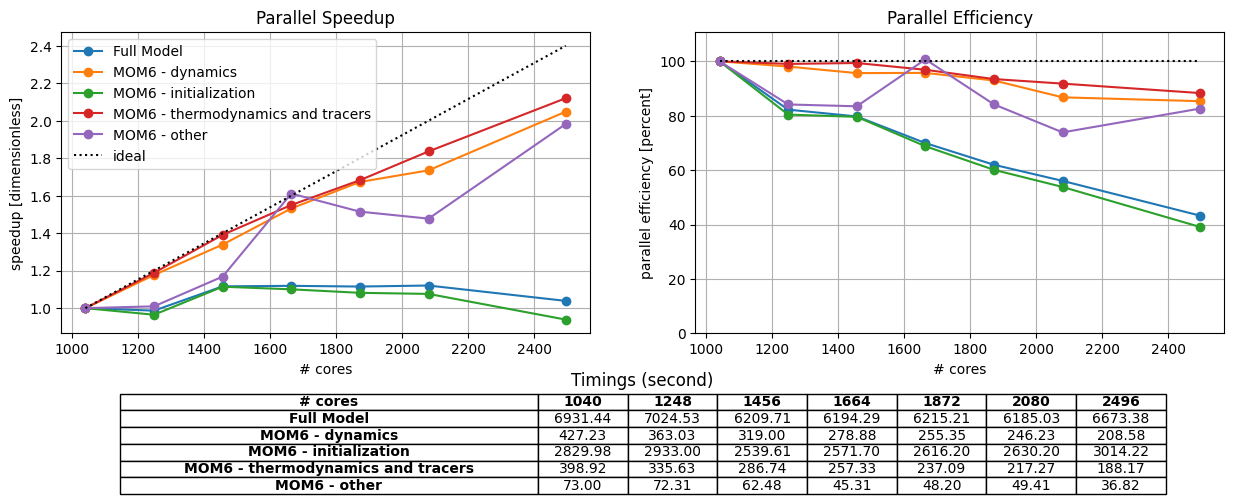

In [8]:
# Plot the scaling data, using only the best experiments
fig = om3_profiling.plot_scaling_data(
    components=["payu", "MOM6"],
    regions=[
        ["payu_model_run_duration_seconds"],
        ["Ocean dynamics", "Ocean Initialization", "Ocean thermodynamics and tracers", "Ocean Other"],
    ],
    metric=tmax,
    region_relabel_map={
        "payu_model_run_duration_seconds": "Full Model",
        "Ocean dynamics": "MOM6 - dynamics",
        "Ocean Initialization": "MOM6 - initialization",
        "Ocean thermodynamics and tracers": "MOM6 - thermodynamics and tracers",
        "Ocean Other": "MOM6 - other",
    },
    xlabel="# cores",
)

## Summary

TODO

# Archive

Archive experiments.

In [9]:
om3_profiling.archive_experiments()

Experiment at /g/data/tm70/model_scaling/ACCESS-rOM3/helen/superaus/archive/om3-layout_superAUS_atm_48_cpl_48_ice_48_ocn_1200_rof_48.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-rOM3/helen/superaus/archive/om3-layout_superAUS_atm_80_cpl_80_ice_80_ocn_2000_rof_80.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-rOM3/helen/superaus/archive/om3-layout_superAUS_atm_40_cpl_40_ice_40_ocn_1000_rof_40.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-rOM3/helen/superaus/archive/om3-layout_superAUS_atm_72_cpl_72_ice_72_ocn_1800_rof_72.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-rOM3/helen/superaus/archive/om3-layout_superAUS_atm_64_cpl_64_ice_64_ocn_1600_rof_64.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-rOM3/helen/superaus/archive/om3-layout_superAUS